# Config

Max Fan Load Power: 33.60W


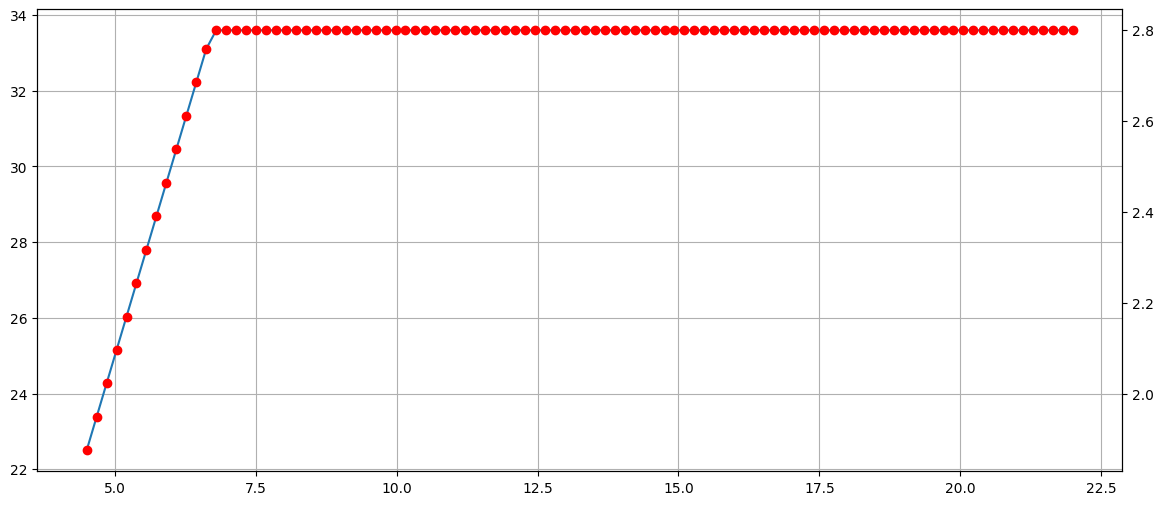

c_out r_esr: 18.34 mOhm


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#USB-C power sources, 5V to 20V, 5A
v_in_min_nominal = 5
v_in_max_nominal = 20
usb_c_v_tolerance = 0.1 # 10% tolerance
v_in = np.linspace(v_in_min_nominal*(1-usb_c_v_tolerance), v_in_max_nominal*(1+usb_c_v_tolerance), 100)
i_in_max = 5 # USB-C PD max current
i_in_nom_max = 3 # common USB-C maximum current
v_out = 12
fan_p14_pro_max_current = 0.35
fan_p14_pwm_max_current = 0.12
max_number_p14_pro = 8
max_load_watts = v_out * fan_p14_pro_max_current * max_number_p14_pro
print(f"Max Fan Load Power: {max_load_watts:.2f}W")

input_voltage_operating_points = v_in
input_current_operating_points_max = np.full_like(input_voltage_operating_points,i_in_nom_max)
f_sw = 100e3 # Assume we use minimum frequency. Helps lower switching mosfet losses. Though increases inductor core/ac losses.

# Calculate max power at each point: min(Available Input Power, Load Limit)
p_out_operating_points = np.minimum(max_load_watts, v_in * i_in_max)
i_out_operating_points = p_out_operating_points / v_out


fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()
ax1.plot(v_in, p_out_operating_points, label='Output Power [W]')
ax2.plot(v_in, i_out_operating_points, 'o', color = "red", label='Output Current [A]')
ax1.grid()
plt.show()

L1 = 47e-6 # from 1_.pynb
c_out_chosen_nominal = 4.7e-3 * 4
c_out_chosen_derated = 4.7e-3 * 4 * 0.7 # 4 4700 uF with 70% dc bias derating
c_out_dissipation_factor = 0.16 + 0.02 * 5
f_df = 120
r_esr = c_out_dissipation_factor / (2 * np.pi * f_df * c_out_chosen_nominal)
print(f"c_out r_esr: {r_esr*1000:.2f} mOhm")

# Average current limiting

In [16]:
# from 6_x_soft start
print(f"{1:0.1f} uF, chosen capacitor")
# from 6_x_feedback resitsors
v_out = 12
r_fb1 = 20e3 # random choice, copy datasheet application. 1kOhm to 100kOhm typical
r_fb2 =  (v_out - 0.8 ) / 0.8 * r_fb1
print(f"r_fb2: {r_fb2/1000:.2f} kOhm")


c_ss = 0.1e-6
v_sns = np.asarray([0.043, 0.050, 0.057])
i_sns = 3e-6
sns_gm = 0.001

v_ss_cl = 1.21
i_ss = np.asarray([3.75, 5, 6.35]) * 1e-6
v_fb_ss_offset = -18e-3

v_ref = np.asarray([0.788, 0.800, 0.812])
v_out_calc_fb = r_fb2/r_fb1 * v_ref + 0.8
print(v_out_calc_fb)

goal_max_average_current_threshold = 3
r_i_sns = v_sns / goal_max_average_current_threshold
print(r_i_sns)

# if tries to draw 4.2A (84W), how long to discharge
overcurrent = 4.2
i_ss_overcurrent = (overcurrent * r_i_sns-v_sns) * sns_gm
time = c_ss / i_ss_overcurrent
print(time)


# untenable. soft start sized to charge up slowly with 5uA ss pullup current. 
# overcurrent is 1 mS, 0.050mV thresh, so 5 mV error to counteract 5uA pullup.
# if we set 10% under vthresh for our max current, then 55mV*1.1 = 60.5mV at 3A.
# Long term is 2.7A at 55mV. 
# At 3A, then 5uA excess pulldown, so discharge SS at same speed we charged SS.
# at 3.3A, then 10uA excess pulldown, so discharge SS at 2x speed of charging

# soft start calculated to charge output caps at about 1/2 the rate of normal max output operating current
# if make is more than 1x, then it would charge output with power higher than we normally can output in steady state.

# if we limit to 60W power, and theroetical unlimited bw, then 0W during low, 60W during high when draw is 84W.
# 24 W difference. if we size bulk output cap to limit dip to 1V, then 
output_current_missing = 24 / 12
dvdt = 1 / (1 / 160 / 2) #speed of output voltage drop if losing 1 V during half cycle
c = output_current_missing / dvdt
print(c)

1.0 uF, chosen capacitor
r_fb2: 280.00 kOhm
[11.832 12.    12.168]
[0.01433333 0.01666667 0.019     ]
[0.00581395 0.005      0.00438596]
0.00625


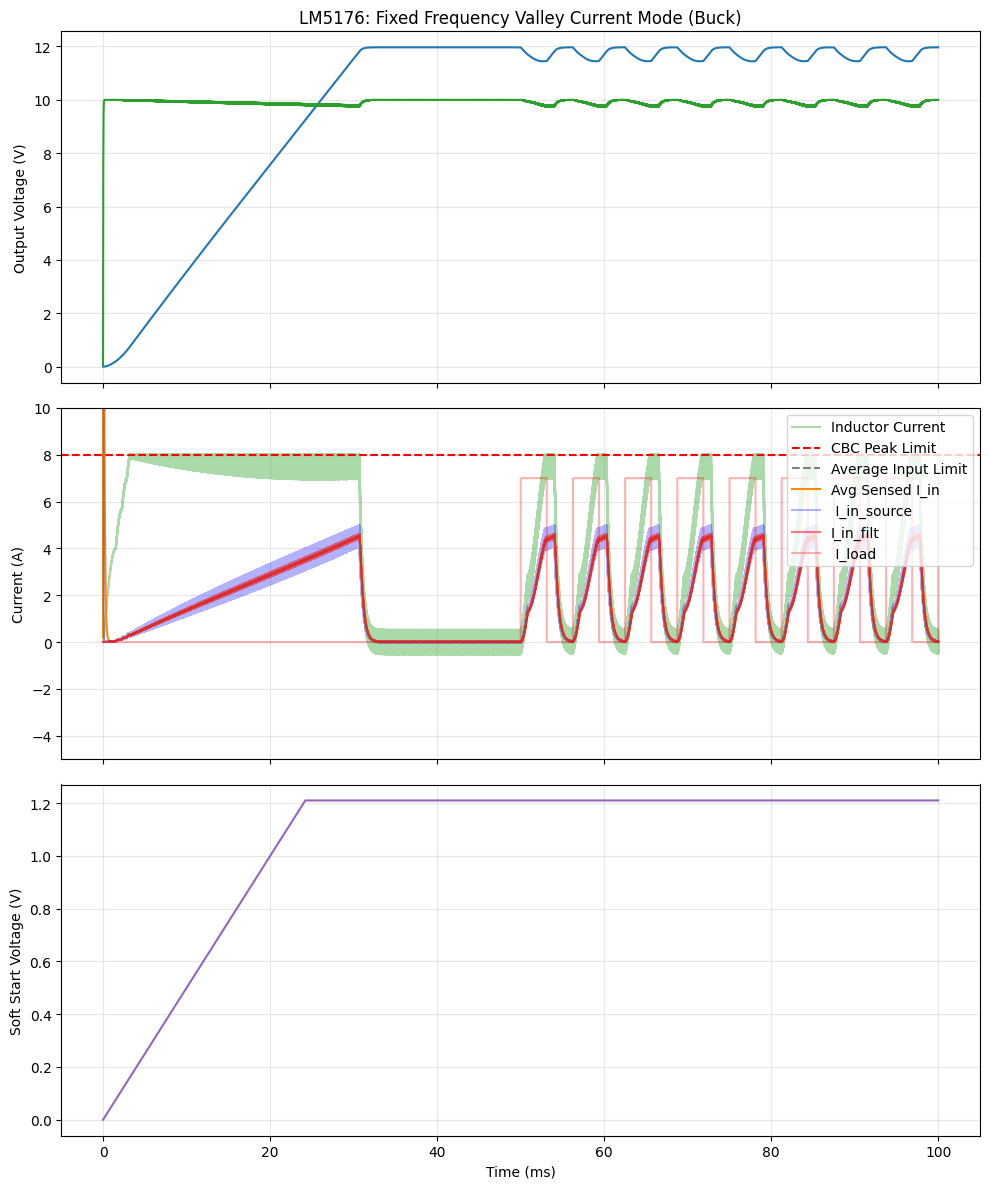

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
V_in_source = 20.0
R_source = 0.1      
C_in = 4*47e-6 + 2*10e-6       
V_out_nom = 12.0
I_load_max = 7.0    
L = 47e-6
C_out = 4*4700e-6 + 9 * 10e-6

# LM5176 Logic
R_isns_in = 0.1e-6 # 20e-3 
V_in_thresh = 0.050 
R_isns_l = 10e-3    
V_l_thresh = 0.080  
I_l_cbc = V_l_thresh / R_isns_l # 4.0A Peak Limit

g_m_ccl = 1e-3          
C_ss = 0.1e-6
I_ss_up = 5e-6
V_ref_fb = 0.8
beta = V_ref_fb / V_out_nom
f_sw = 100000       
T_sw = 1/f_sw

# Simulation Settings
dt = 1e-7           # 100ns for cleaner switching
t_startup = 0.05
t_total = 0.10
steps = int(t_total / dt)

# State Variables
v_in_node = 0#V_in_source
v_out = 0.0
i_l = 0.0
v_ss = 0.0
v_sns_filt = 0.0    
v_i_in_filt = 0.0
r_filt, c_filt = 1000, 100e-9
high_side_on = False
last_clock = -T_sw

# Results
time = np.linspace(0, t_total, steps)
log_v_out = np.zeros(steps)
log_v_in_node = np.zeros(steps)
log_i_l = np.zeros(steps)
log_i_in_sns_avg = np.zeros(steps)
log_v_ss = np.zeros(steps)
log_i_in_source = np.zeros(steps)
log_i_load = np.zeros(steps)
log_i_in_filt = np.zeros(steps)

for i in range(steps):
    t = time[i]
    
    # 1. Load Profile
    i_load = I_load_max if (t > t_startup and (t % (1/160)) < (1/320)) else 0.0
    
    # 2. Valley Target from Control Loop
    v_target = min(v_ss, V_ref_fb) / beta
    # Valley current target (Setpoint for when to allow the next HS turn-on)
    i_valley_target = (v_target - v_out) * 50.0 + (i_load - 2.0) 
    
    # 3. Fixed Frequency / Valley Logic
    # Check if we are at a new clock cycle
    if (t - last_clock) >= T_sw:
        # In Valley Mode, we turn ON at the clock IF current is below valley setpoint
        if i_l <= i_valley_target:
            high_side_on = True
            last_clock = t
            
    # HS stays on for Ton. In LM5176 Buck, Ton is ~ (Vout/Vin)*T_sw
    t_on_target = (max(v_out, 0.1) / max(v_in_node, 1.0)) * T_sw
    
    if high_side_on:
        # Turn OFF if Ton is reached OR if 4A CBC Peak limit is hit
        if (t - last_clock) >= t_on_target or i_l >= I_l_cbc:
            high_side_on = False

    # 4. Inductor Physics
    v_l = (v_in_node - v_out) if high_side_on else -v_out
    i_l += (v_l / L) * dt
    
    # 5. Input Rail & Average Sense
    i_in_sw = i_l if high_side_on else 0.0
    i_in_source = (V_in_source - v_in_node)/R_source
    v_in_node += (((V_in_source - v_in_node)/R_source) - i_in_sw) * (dt/C_in)
    v_i_in_filt += ((i_in_sw * R_isns_in - v_i_in_filt) / (r_filt * c_filt)) * dt
    v_sns_filt += ((i_in_source * R_isns_in - v_sns_filt) / (r_filt * c_filt)) * dt

    # 6. Soft Start & Output Cap
    i_ss_down = g_m_ccl * max(0, v_sns_filt - V_in_thresh)
    v_ss = np.clip(v_ss + ((I_ss_up - i_ss_down) / C_ss) * dt, 0, 1.21)
    v_out += ((i_l - i_load) / C_out) * dt
    
    # Log
    log_v_out[i], log_v_in_node[i], log_i_l[i], log_i_in_sns_avg[i], log_v_ss[i] = v_out, v_in_node, i_l, v_sns_filt/R_isns_in, v_ss
    log_i_in_source[i] = (V_in_source - v_in_node)/R_source
    log_i_load[i] = i_load
    log_i_in_filt[i] = v_i_in_filt / R_isns_in

# --- Plotting ---
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

ax1.plot(time*1000, log_v_out, color='tab:blue', label='V_out')
ax1.plot(time*1000, log_v_in_node/2, color='tab:green', label='V_in/2')
ax1.set_ylabel('Output Voltage (V)')
ax1.grid(True, alpha=0.3)
ax1.set_title("LM5176: Fixed Frequency Valley Current Mode (Buck)")

ax2.plot(time*1000, log_i_l, color='tab:green', alpha=0.4, label='Inductor Current')
ax2.axhline(I_l_cbc, color='red', linestyle='--', label='CBC Peak Limit')
ax2.axhline(V_in_thresh / R_isns_in, color='grey', linestyle='--', label='Average Input Limit')
ax2.plot(time*1000, log_i_in_sns_avg, color='darkorange', label='Avg Sensed I_in')
ax2.plot(time*1000, log_i_in_source, color='blue', label=' I_in_source', alpha = 0.3)
ax2.plot(time*1000, log_i_in_filt, color='red', label='I_in_filt', alpha = 0.5)
ax2.plot(time*1000, log_i_load, color='red', label=' I_load', alpha = 0.3)
ax2.set_ylabel('Current (A)')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)
ax2.set_ylim([-5,10])
#ax2.set_xlim([24,30])

ax3.plot(time*1000, log_v_ss, color='tab:purple', label='V_ss')
ax3.set_ylabel('Soft Start Voltage (V)')
ax3.set_xlabel('Time (ms)')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

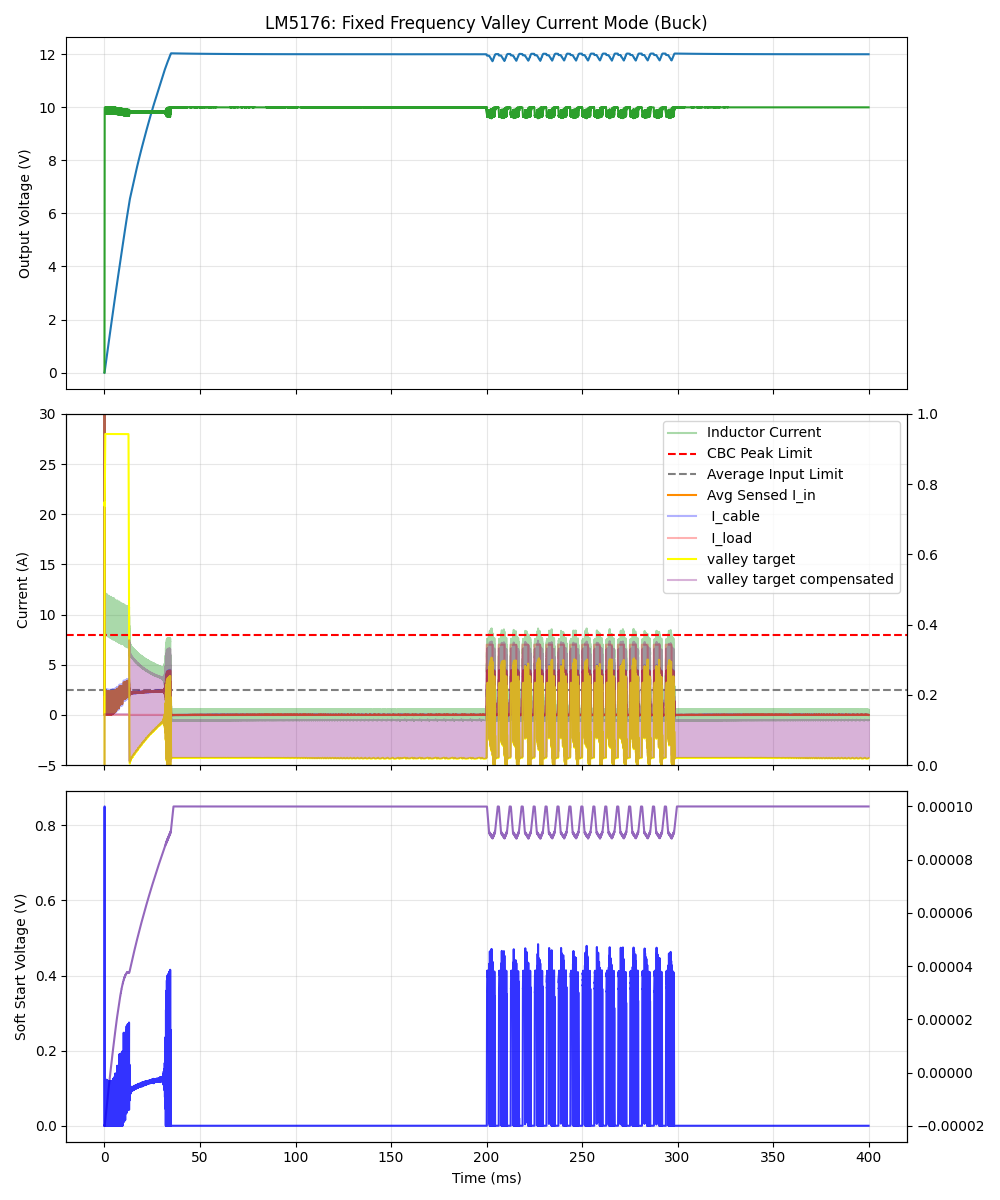

In [40]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget

# --- Parameters ---
V_in_source = 20.0
# USB-C Cable Physics (1-meter typical)
L_cable = 1.0e-6      # 1uH stray inductance
R_cable = 0.15        # Resistance of wires + connectors (150mOhm)

C_in = 4*47e-6 + 2*1e-6       
V_out_nom = 12.0
I_load_max = 7.0    
L = 47e-6
C_out = 4*4700e-6 + 9 * 1e-6

#f_bw = 700 # v2, choose fast response. 1/3 of rhp boost
#f_zc = 6 # 1.5 times fp1boost, about 3x fp1buck
#f_pc2 = 5000 #7 to 10 times f_bw

r_comp = 79500 #2*np.pi*1.31e-3*(280000+20000)/20000*5*0.01/(5/12)*(4.7e-3*4*0.7) *f_bw #79.5k
c_comp = 300e-9#1 / (2*np.pi*f_zc*r_comp) # 220n old, 334n new
c_hf = 400e-12 #1 / (2*np.pi*f_pc2*r_comp) # 400pf new, old150e-9 
c_slope = 330e-12

# LM5176 Logic
R_isns_in = 20e-3 # 20e-3 
V_in_thresh = 0.050 
R_isns_l = 10e-3    
V_l_thresh = 0.080  
I_l_cbc = V_l_thresh / R_isns_l # 8.0A Peak Limit
gm_slope = 2e-6
a_cs = 5

g_m_ccl = 1e-3
v_fb_ss_offset = -18e-3
gm_ea = 1.31e-3      
C_ss = 0.5e-6
I_ss_up = 5e-6
V_ref_fb = 0.8
beta = V_ref_fb / V_out_nom
f_sw = 100000       
T_sw = 1/f_sw

# Simulation Settings
dt = 1e-7           # 100ns for cleaner switching
t_startup = 0.2
t_off = 0.3
t_total = 0.4
steps = int(t_total / dt)

# State Variables
v_in_node = 0#V_in_source
i_cable = 0
v_out = 0.0
i_l = 0.0
v_ss = 0.0
v_sns_filt = 0.0    
v_i_in_filt = 0.0
r_filt, c_filt = 500, 10e-9
high_side_on = False
last_clock = -T_sw
# --- New State Variables for COMP Pin ---
v_comp = 1.0        # The actual voltage on the COMP pin (Top of C_hf)
v_c_comp = 1.0      # The voltage across the "bulk" capacitor C_comp only
v_fb = 0.0      # Feedback voltage
i_comp = 0.0    # Current out of Gm amplifier
cbc_limit_flag = False

# Results
time = np.linspace(0, t_total, steps)
log_v_out = np.zeros(steps)
log_v_in_node = np.zeros(steps)
log_i_l = np.zeros(steps)
log_i_in_sns_avg = np.zeros(steps)
log_v_ss = np.zeros(steps)
log_i_in_source = np.zeros(steps)
log_i_load = np.zeros(steps)
log_i_cable = np.zeros(steps)
log_i_in_filt = np.zeros(steps)
log_v_comp = np.zeros(steps)
log_i_valley_target_compensated = np.zeros(steps)
log_i_ss_down = np.zeros(steps)

for i in range(steps):
    t = time[i]
    
    # 1. Load Profile
    i_load = I_load_max if (t > t_startup and t < t_off and (t % (1/160)) < (1/320)) else 0.01
    
    # 2. FEEDBACK & ERROR AMP LOGIC (The "Pro" Way)
    # The FB pin sees V_out through the resistor divider
    v_fb = v_out * beta 
    
    # Current into COMP pin: i = gm * (Vref - Vfb)
    # Limited by the 280uA source/sink capability you provided
    i_err_amp_raw = gm_ea * (min(v_ss-v_fb_ss_offset, V_ref_fb) - v_fb)
    i_err_amp = np.clip(i_err_amp_raw, -280e-6, 280e-6)
    
    # 1. Calculate current flowing through the Resistor branch
    # This depends on the difference between the COMP pin and the bulk capacitor
    i_r_branch = (v_comp - v_c_comp) / r_comp

    # 2. Update the COMP pin voltage
    # The net current into the COMP node is (i_err_amp - i_r_branch).
    # This current charges/discharges C_hf.
    dv_comp = ((i_err_amp - i_r_branch) / c_hf) * dt
    v_comp += dv_comp

    # 3. Update the Bulk Capacitor voltage
    # The current that went through the resistor now charges C_comp.
    dv_c_comp = (i_r_branch / c_comp) * dt
    v_c_comp += dv_c_comp

    # 4. Limit v_comp to the chip's physical rails (usually 0V to ~3.3V)
    v_comp = np.clip(v_comp, 0.3, 3.0)
    
    # 4. TRANSLATE COMP TO CURRENT TARGET
    # In most controllers, I_target = (V_comp - offset) * Gain
    # Adjust 1.2 and 5.0 to match your specific IC's 
    i_valley_target = (v_comp - 1.6) / a_cs / R_isns_l

    # --- Real LM5176 Deadbeat Physics ---
    # The IC senses Vout to set the falling-edge compensation in Buck mode
    i_slope_internal = gm_slope * (v_in_node - v_out) 

    # Voltage slope on the COMP pin
    dv_slope_dt = i_slope_internal / c_slope 

    # Effective Amps slope (what the comparator 'thinks' is happening)
    se_eff = dv_slope_dt / (R_isns_l * a_cs)

    # Update the target
    t_cycle = (t - last_clock)
    slope_ramp = se_eff * t_cycle
    i_valley_target_compensated = min(I_l_cbc, i_valley_target + slope_ramp)
    log_i_valley_target_compensated[i] = i_valley_target_compensated

    
    # 3. Fixed Frequency / Valley Logic
    # Check if we are at a new clock cycle
    if i_l <= i_valley_target_compensated and not(cbc_limit_flag):
        high_side_on = True
    #if i_l >= I_l_cbc:
    ## Turn OFF if Ton is reached OR if 4A CBC Peak limit is hit
    #    cbc_limit_flag = True
    #    high_side_on = False
    if high_side_on or cbc_limit_flag:
        log_i_valley_target_compensated[i] = log_i_valley_target_compensated[i-1]
    if (t - last_clock) >= T_sw:
        cbc_limit_flag = False
        if i_l>I_l_cbc:# high_side_on == False: #never turned on
            cbc_limit_flag = True
        high_side_on = False
        # In Valley Mode, we turn ON at the clock IF current is below valley setpoint
        last_clock = t
    
        
    # HS stays on for Ton. In LM5176 Buck, Ton is ~ (Vout/Vin)*T_sw
    #t_on_target = (max(v_out, 0.1) / max(v_in_node, 1.0)) * T_sw


    # 4. Inductor Physics
    v_l = (v_in_node - v_out) if high_side_on else -v_out
    i_l += (v_l / L) * dt

    # 5. USB-C CABLE & INPUT RAIL PHYSICS (The LC Pi Filter)
    # Cable current: di/dt = (V_source - V_drop_R - V_pcb) / L_cable
    di_cable = (V_in_source - (i_cable * R_cable) - v_in_node) / L_cable
    i_cable += di_cable * dt
    
    # 5. Input Rail & Average Sense
    i_in_sw = i_l if high_side_on else 0.0
    #i_in_source = (V_in_source - v_in_node)/R_source
    #v_in_node += (((V_in_source - v_in_node)/R_source) - i_in_sw) * (dt/C_in)
    v_in_node += (i_cable - i_in_sw) * (dt / C_in)
    #v_i_in_filt += ((i_in_sw * R_isns_in - v_i_in_filt) / (r_filt * c_filt)) * dt
    v_sns_filt += ((i_cable * R_isns_in - v_sns_filt) / (r_filt * c_filt)) * dt

    # 6. Soft Start & Output Cap
    i_ss_down = np.clip(g_m_ccl * (v_sns_filt - V_in_thresh), -20e-6, 100e-6) #allow -20 pulldown, not realistic for lm5176, but maybe with external circuit
    v_ss = np.clip(v_ss + ((I_ss_up - i_ss_down) / C_ss) * dt, 0, 0.85) #1.21 from datasheet but test cap manually externally
    v_out += ((i_l - i_load) / C_out) * dt
    
    # Log
    log_v_out[i], log_v_in_node[i], log_i_l[i], log_i_in_sns_avg[i], log_v_ss[i] = v_out, v_in_node, i_l, v_sns_filt/R_isns_in, v_ss
    #log_i_in_source[i] = (V_in_source - v_in_node)/R_cable
    log_i_load[i] = i_load
    log_i_cable[i] = i_cable
    log_i_in_filt[i] = v_i_in_filt / R_isns_in
    log_v_comp[i] = v_comp
    log_i_ss_down[i] = i_ss_down

# --- Plotting ---
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

ax1.plot(time*1000, log_v_out, color='tab:blue', label='V_out')
ax1.plot(time*1000, log_v_in_node/2, color='tab:green', label='V_in/2')
ax1.set_ylabel('Output Voltage (V)')
ax1.grid(True, alpha=0.3)
ax1.set_title("LM5176: Fixed Frequency Valley Current Mode (Buck)")

ax2.plot(time*1000, log_i_l, color='tab:green', alpha=0.4, label='Inductor Current')
ax2.axhline(I_l_cbc, color='red', linestyle='--', label='CBC Peak Limit')
ax2.axhline(V_in_thresh / R_isns_in, color='grey', linestyle='--', label='Average Input Limit')
ax2.plot(time*1000, log_i_in_sns_avg, color='darkorange', label='Avg Sensed I_in')
#ax2.plot(time*1000, log_i_in_source, color='blue', label=' I_in_source', alpha = 0.3)
ax2.plot(time*1000, log_i_cable, color='blue', label=' I_cable', alpha = 0.3)
#ax2.plot(time*1000, log_i_in_filt, color='red', label='I_in_filt', alpha = 0.5)
ax2.plot(time*1000, log_i_load, color='red', label=' I_load', alpha = 0.3)
voltage_plot = ax2.twinx()
ax2.plot(time*1000, (log_v_comp - 1.6) / a_cs / R_isns_l, color='yellow', label='valley target', alpha = 1)
ax2.plot(time*1000, log_i_valley_target_compensated, color='purple', label='valley target compensated', alpha = 0.3)
ax2.set_ylabel('Current (A)')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)
ax2.set_ylim([-5,30])
#ax2.set_xlim([30,33])

ax3.plot(time*1000, log_v_ss, color='tab:purple', label='V_ss')
ax3twin = ax3.twinx()
ax3twin.plot(time*1000, log_i_ss_down, color='blue', label=' I_ss_down', alpha = 0.8)
ax3.set_ylabel('Soft Start Voltage (V)')
ax3.set_xlabel('Time (ms)')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Version 1 PCB

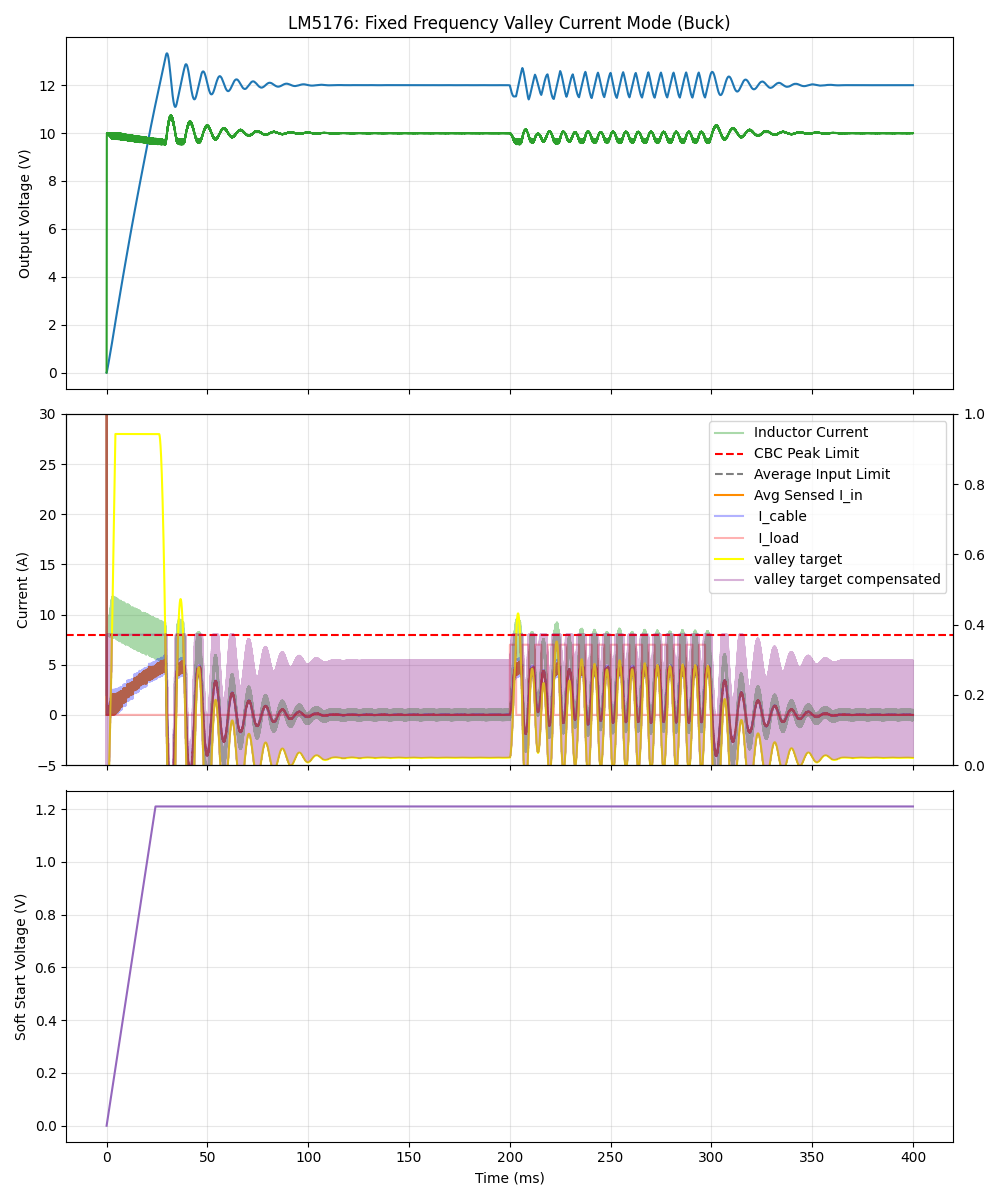

In [26]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget

# --- Parameters ---
V_in_source = 20.0
# USB-C Cable Physics (1-meter typical)
L_cable = 1.0e-6      # 1uH stray inductance
R_cable = 0.15        # Resistance of wires + connectors (150mOhm)

C_in = 4*47e-6 + 2*1e-6       
V_out_nom = 12.0
I_load_max = 7.0    
L = 47e-6
C_out = 4*4700e-6 + 9 * 1e-6
r_comp = 100e3
c_comp = 220e-9 
c_hf = 150e-9
c_slope = 330e-12

# LM5176 Logic
R_isns_in = 0.1e-6 # 20e-3 
V_in_thresh = 0.050 
R_isns_l = 10e-3    
V_l_thresh = 0.080  
I_l_cbc = V_l_thresh / R_isns_l # 8.0A Peak Limit
gm_slope = 2e-6
a_cs = 5

g_m_ccl = 1e-3
v_fb_ss_offset = -18e-3
gm_ea = 1.31e-3      
C_ss = 0.1e-6
I_ss_up = 5e-6
V_ref_fb = 0.8
beta = V_ref_fb / V_out_nom
f_sw = 100000       
T_sw = 1/f_sw

# Simulation Settings
dt = 1e-7           # 100ns for cleaner switching
t_startup = 0.2
t_off = 0.3
t_total = 0.4
steps = int(t_total / dt)

# State Variables
v_in_node = 0#V_in_source
i_cable = 0
v_out = 0.0
i_l = 0.0
v_ss = 0.0
v_sns_filt = 0.0    
v_i_in_filt = 0.0
r_filt, c_filt = 1000, 10e-9
high_side_on = False
last_clock = -T_sw
# --- New State Variables for COMP Pin ---
v_comp = 1.0        # The actual voltage on the COMP pin (Top of C_hf)
v_c_comp = 1.0      # The voltage across the "bulk" capacitor C_comp only
v_fb = 0.0      # Feedback voltage
i_comp = 0.0    # Current out of Gm amplifier
cbc_limit_flag = False

# Results
time = np.linspace(0, t_total, steps)
log_v_out = np.zeros(steps)
log_v_in_node = np.zeros(steps)
log_i_l = np.zeros(steps)
log_i_in_sns_avg = np.zeros(steps)
log_v_ss = np.zeros(steps)
log_i_in_source = np.zeros(steps)
log_i_load = np.zeros(steps)
log_i_cable = np.zeros(steps)
log_i_in_filt = np.zeros(steps)
log_v_comp = np.zeros(steps)
log_i_valley_target_compensated = np.zeros(steps)

for i in range(steps):
    t = time[i]
    
    # 1. Load Profile
    i_load = I_load_max if (t > t_startup and t < t_off and (t % (1/160)) < (1/320)) else 0.01
    
    # 2. FEEDBACK & ERROR AMP LOGIC (The "Pro" Way)
    # The FB pin sees V_out through the resistor divider
    v_fb = v_out * beta 
    
    # Current into COMP pin: i = gm * (Vref - Vfb)
    # Limited by the 280uA source/sink capability you provided
    i_err_amp_raw = gm_ea * (min(v_ss-v_fb_ss_offset, V_ref_fb) - v_fb)
    i_err_amp = np.clip(i_err_amp_raw, -280e-6, 280e-6)
    
    # 1. Calculate current flowing through the Resistor branch
    # This depends on the difference between the COMP pin and the bulk capacitor
    i_r_branch = (v_comp - v_c_comp) / r_comp

    # 2. Update the COMP pin voltage
    # The net current into the COMP node is (i_err_amp - i_r_branch).
    # This current charges/discharges C_hf.
    dv_comp = ((i_err_amp - i_r_branch) / c_hf) * dt
    v_comp += dv_comp

    # 3. Update the Bulk Capacitor voltage
    # The current that went through the resistor now charges C_comp.
    dv_c_comp = (i_r_branch / c_comp) * dt
    v_c_comp += dv_c_comp

    # 4. Limit v_comp to the chip's physical rails (usually 0V to ~3.3V)
    v_comp = np.clip(v_comp, 0.3, 3.0)
    
    # 4. TRANSLATE COMP TO CURRENT TARGET
    # In most controllers, I_target = (V_comp - offset) * Gain
    # Adjust 1.2 and 5.0 to match your specific IC's 
    i_valley_target = (v_comp - 1.6) / a_cs / R_isns_l

    # --- Real LM5176 Deadbeat Physics ---
    # The IC senses Vout to set the falling-edge compensation in Buck mode
    i_slope_internal = gm_slope * (v_in_node - v_out) 

    # Voltage slope on the COMP pin
    dv_slope_dt = i_slope_internal / c_slope 

    # Effective Amps slope (what the comparator 'thinks' is happening)
    se_eff = dv_slope_dt / (R_isns_l * a_cs)

    # Update the target
    t_cycle = (t - last_clock)
    slope_ramp = se_eff * t_cycle
    i_valley_target_compensated = min(I_l_cbc, i_valley_target + slope_ramp)
    log_i_valley_target_compensated[i] = i_valley_target_compensated

    
    # 3. Fixed Frequency / Valley Logic
    # Check if we are at a new clock cycle
    if i_l <= i_valley_target_compensated and not(cbc_limit_flag):
        high_side_on = True
    #if i_l >= I_l_cbc:
    ## Turn OFF if Ton is reached OR if 4A CBC Peak limit is hit
    #    cbc_limit_flag = True
    #    high_side_on = False
    #if high_side_on or cbc_limit_flag:
    #    log_i_valley_target_compensated[i] = log_i_valley_target_compensated[i-1]
    if (t - last_clock) >= T_sw:
        cbc_limit_flag = False
        if i_l>I_l_cbc:# high_side_on == False: #never turned on
            cbc_limit_flag = True
        high_side_on = False
        # In Valley Mode, we turn ON at the clock IF current is below valley setpoint
        last_clock = t
        

        
    # HS stays on for Ton. In LM5176 Buck, Ton is ~ (Vout/Vin)*T_sw
    #t_on_target = (max(v_out, 0.1) / max(v_in_node, 1.0)) * T_sw


    # 4. Inductor Physics
    v_l = (v_in_node - v_out) if high_side_on else -v_out
    i_l += (v_l / L) * dt

    # 5. USB-C CABLE & INPUT RAIL PHYSICS (The LC Pi Filter)
    # Cable current: di/dt = (V_source - V_drop_R - V_pcb) / L_cable
    di_cable = (V_in_source - (i_cable * R_cable) - v_in_node) / L_cable
    i_cable += di_cable * dt
    
    # 5. Input Rail & Average Sense
    i_in_sw = i_l if high_side_on else 0.0
    #i_in_source = (V_in_source - v_in_node)/R_source
    #v_in_node += (((V_in_source - v_in_node)/R_source) - i_in_sw) * (dt/C_in)
    v_in_node += (i_cable - i_in_sw) * (dt / C_in)
    #v_i_in_filt += ((i_in_sw * R_isns_in - v_i_in_filt) / (r_filt * c_filt)) * dt
    v_sns_filt += ((i_cable * R_isns_in - v_sns_filt) / (r_filt * c_filt)) * dt

    # 6. Soft Start & Output Cap
    i_ss_down = g_m_ccl * max(0, v_sns_filt - V_in_thresh)
    v_ss = np.clip(v_ss + ((I_ss_up - i_ss_down) / C_ss) * dt, 0, 1.21)
    v_out += ((i_l - i_load) / C_out) * dt
    
    # Log
    log_v_out[i], log_v_in_node[i], log_i_l[i], log_i_in_sns_avg[i], log_v_ss[i] = v_out, v_in_node, i_l, v_sns_filt/R_isns_in, v_ss
    #log_i_in_source[i] = (V_in_source - v_in_node)/R_cable
    log_i_load[i] = i_load
    log_i_cable[i] = i_cable
    log_i_in_filt[i] = v_i_in_filt / R_isns_in
    log_v_comp[i] = v_comp

# --- Plotting ---
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

ax1.plot(time*1000, log_v_out, color='tab:blue', label='V_out')
ax1.plot(time*1000, log_v_in_node/2, color='tab:green', label='V_in/2')
ax1.set_ylabel('Output Voltage (V)')
ax1.grid(True, alpha=0.3)
ax1.set_title("LM5176: Fixed Frequency Valley Current Mode (Buck)")

ax2.plot(time*1000, log_i_l, color='tab:green', alpha=0.4, label='Inductor Current')
ax2.axhline(I_l_cbc, color='red', linestyle='--', label='CBC Peak Limit')
ax2.axhline(V_in_thresh / R_isns_in, color='grey', linestyle='--', label='Average Input Limit')
ax2.plot(time*1000, log_i_in_sns_avg, color='darkorange', label='Avg Sensed I_in')
#ax2.plot(time*1000, log_i_in_source, color='blue', label=' I_in_source', alpha = 0.3)
ax2.plot(time*1000, log_i_cable, color='blue', label=' I_cable', alpha = 0.3)
#ax2.plot(time*1000, log_i_in_filt, color='red', label='I_in_filt', alpha = 0.5)
ax2.plot(time*1000, log_i_load, color='red', label=' I_load', alpha = 0.3)
voltage_plot = ax2.twinx()
ax2.plot(time*1000, (log_v_comp - 1.6) / a_cs / R_isns_l, color='yellow', label='valley target', alpha = 1)
ax2.plot(time*1000, log_i_valley_target_compensated, color='purple', label='valley target compensated', alpha = 0.3)
ax2.set_ylabel('Current (A)')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)
ax2.set_ylim([-5,30])
#ax2.set_xlim([30,33])

ax3.plot(time*1000, log_v_ss, color='tab:purple', label='V_ss')
ax3.set_ylabel('Soft Start Voltage (V)')
ax3.set_xlabel('Time (ms)')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()